# Classificador de Risco de NEOs (PHA)

Pipeline de classificação binária supervisionada que prevê se um asteroide é
**potencialmente perigoso (PHA)**, usando apenas técnicas vistas na disciplina
(MLP, XGBoost, StandardScaler, SHAP). Fonte: **NASA NeoWs** (`browse`).

> **Nota anti-vazamento:** o rótulo PHA é definido por tamanho (H <= 22) **e**
> proximidade orbital (MOID <= 0,05 UA). Removemos o **MOID** das features; a
> magnitude absoluta (que codifica o critério de tamanho) é mantida como
> variável física legítima e isso é declarado abertamente.
>
> **Protocolo de avaliação:** split estratificado em **3 conjuntos** —
> treino (60%) / validação (20%) / teste (20%). A escolha do modelo é feita na
> **validação**; as métricas finais são reportadas no **teste intocado**.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from xgboost import XGBClassifier, plot_importance

from src.neo_features import FEATURE_COLUMNS, TARGET_COLUMN

RANDOM_STATE = 42


## 1. Dados e EDA

In [2]:
df = pd.read_csv("data/neos_raw.csv")
print("shape:", df.shape)
df.head()


shape: (18447, 10)


,designation,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,miss_distance_min_au,miss_distance_mean_au,relative_velocity_max_kms,n_close_approaches,is_potentially_hazardous_asteroid
0,1620,1620 Geographos (1951 RA),15.27,2.347226,5.248558,0.033305,0.115975,16.737430,28,1
1,1863,1863 Antinous (1948 EA),15.32,2.293797,5.129086,0.174222,0.182551,18.043920,6,0
2,1915,1915 Quetzalcoatl (1953 EA),18.38,0.560473,1.253257,0.025332,0.199618,19.519999,21,0
3,1917,1917 Cuyo (1968 AA),14.38,3.536348,7.907514,0.072944,0.118651,16.404789,6,0
4,2063,2063 Bacchus (1977 HB),17.21,0.960627,2.148028,0.067753,0.130982,16.145461,33,0


is_potentially_hazardous_asteroid
0    16528
1     1919
Name: count, dtype: int64
Prevalência de PHA no conjunto: 10.4%


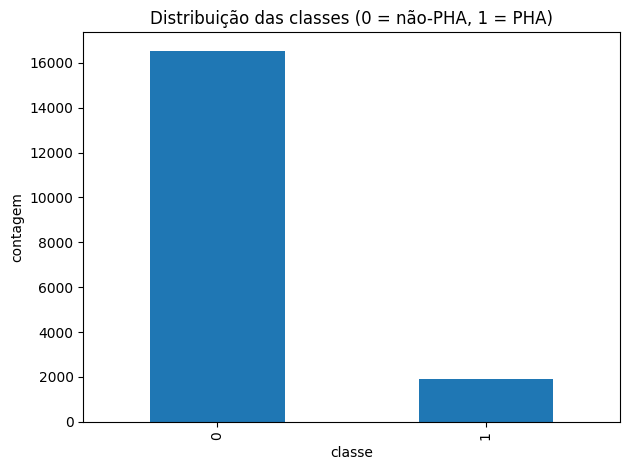

In [3]:
counts = df[TARGET_COLUMN].value_counts().sort_index()
prevalence = df[TARGET_COLUMN].mean()
print(counts)
print(f"Prevalência de PHA no conjunto: {prevalence:.1%}")
counts.plot(kind="bar")
plt.title("Distribuição das classes (0 = não-PHA, 1 = PHA)")
plt.xlabel("classe"); plt.ylabel("contagem"); plt.tight_layout(); plt.show()


### Correlação e redundância de tamanho

A NeoWs deriva `estimated_diameter` de `absolute_magnitude_h` (via albedo), então
os campos de tamanho são colineares por construção. O heatmap confirma isso e
justifica manter **uma única** feature de tamanho (`absolute_magnitude_h`).


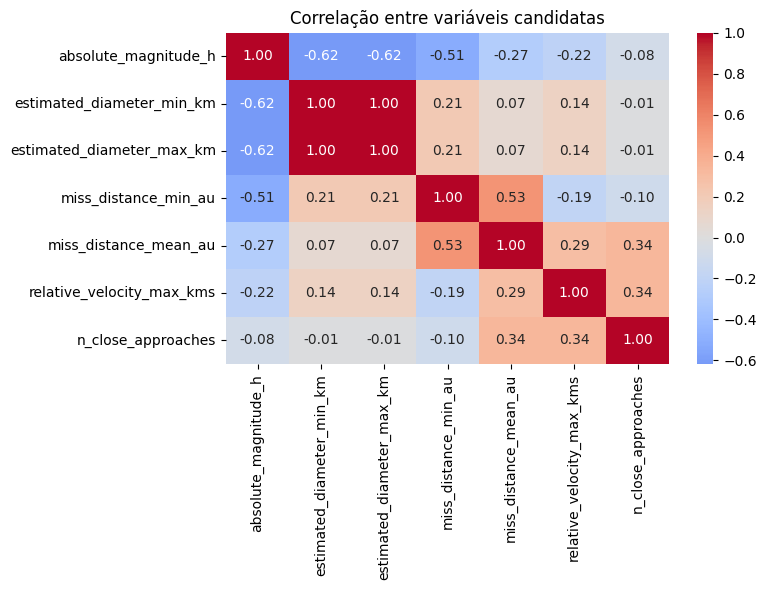

In [4]:
size_and_features = [
    "absolute_magnitude_h", "estimated_diameter_min_km", "estimated_diameter_max_km",
    "miss_distance_min_au", "miss_distance_mean_au",
    "relative_velocity_max_kms", "n_close_approaches",
]
corr = df[size_and_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlação entre variáveis candidatas")
plt.tight_layout(); plt.show()


## 2. Pré-processamento, split 3-vias e persistência

- Features = `FEATURE_COLUMNS` (uma de tamanho + aproximação); diâmetros saem por
  redundância (heatmap acima).
- Split **estratificado** em treino (60%) / validação (20%) / teste (20%), `random_state=42`.
- `StandardScaler` ajustado **apenas no treino** (sem vazamento de escala).
- Os splits são persistidos em `data/neos_split.csv` (coluna `split`), reprodutíveis.


In [5]:
X = df[FEATURE_COLUMNS]
y = df[TARGET_COLUMN]

# 60% treino / 20% validação / 20% teste (estratificado)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_STATE, stratify=y_temp
)

# Persistir os splits em disco (coluna 'split'), reprodutível e inspecionável
split_col = pd.Series(index=df.index, dtype=object)
split_col.loc[X_train.index] = "train"
split_col.loc[X_val.index] = "val"
split_col.loc[X_test.index] = "test"
df_split = df.copy()
df_split["split"] = split_col
df_split.to_csv("data/neos_split.csv", index=False)

# Scaler ajustado SÓ no treino; DataFrames nomeados (SHAP/plot_importance legíveis)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=FEATURE_COLUMNS, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=FEATURE_COLUMNS, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=FEATURE_COLUMNS, index=X_test.index)

print("treino:", X_train.shape, "| validação:", X_val.shape, "| teste:", X_test.shape)
print("PHA  treino/val/teste:", int(y_train.sum()), "/", int(y_val.sum()), "/", int(y_test.sum()))
print("splits salvos em data/neos_split.csv (coluna 'split')")


treino: (11067, 5) | validação: (3690, 5) | teste: (3690, 5)
PHA  treino/val/teste: 1151 / 384 / 384
splits salvos em data/neos_split.csv (coluna 'split')


## 3. Modelos: XGBoost e MLP (treinados no conjunto de treino)

Duas técnicas distintas, ambas ensinadas. O XGBoost usa `scale_pos_weight` (calculado
no treino) para o desbalanceamento; o `MLPClassifier` do sklearn não tem equivalente.


In [6]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos
print("scale_pos_weight =", round(scale_pos_weight, 3))

xgb = XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE, eval_metric="logloss",
)
xgb.fit(X_train_scaled, y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32), activation="relu", max_iter=500, random_state=RANDOM_STATE,
)
mlp.fit(X_train_scaled, y_train)
print("modelos treinados no conjunto de TREINO")


scale_pos_weight = 8.615


/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


modelos treinados no conjunto de TREINO


## 4. Seleção do modelo na VALIDAÇÃO

A escolha do modelo é feita **na validação** (nunca no teste). Critério de domínio:
**recall da classe PHA** — em defesa planetária, um falso negativo (deixar passar um
asteroide perigoso) é muito mais caro do que um falso alarme.


In [7]:
def metrics_row(name, model, Xs, yt):
    pred = model.predict(Xs)
    return {
        "modelo": name,
        "accuracy": accuracy_score(yt, pred),
        "precision_PHA": precision_score(yt, pred, zero_division=0),
        "recall_PHA": recall_score(yt, pred, zero_division=0),
        "f1_PHA": f1_score(yt, pred, zero_division=0),
    }

val_comparison = pd.DataFrame([
    metrics_row("XGBoost", xgb, X_val_scaled, y_val),
    metrics_row("MLP", mlp, X_val_scaled, y_val),
])
print("=== Métricas na VALIDAÇÃO (base da escolha) ===")
print(val_comparison.to_string(index=False))

best_idx = val_comparison["recall_PHA"].idxmax()
best_name = val_comparison.loc[best_idx, "modelo"]
best_model = {"XGBoost": xgb, "MLP": mlp}[best_name]
print("\nModelo escolhido (maior recall_PHA na validação):", best_name)


=== Métricas na VALIDAÇÃO (base da escolha) ===
 modelo  accuracy  precision_PHA  recall_PHA   f1_PHA
XGBoost  0.932791       0.623188    0.895833 0.735043
    MLP  0.959892       0.861963    0.731771 0.791549

Modelo escolhido (maior recall_PHA na validação): XGBoost


/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


## 5. Avaliação final no TESTE (intocado)

As métricas abaixo são do **modelo escolhido na validação**, avaliado no conjunto
de **teste**, que não participou de treino nem de seleção. Mostramos também os dois
modelos no teste apenas como referência de transparência.


=== Ambos no TESTE (referência; a seleção foi na validação) ===
 modelo  accuracy  precision_PHA  recall_PHA   f1_PHA
XGBoost  0.934959       0.628571    0.916667 0.745763
    MLP  0.962331       0.876923    0.742188 0.803949

=== Métricas FINAIS — modelo escolhido (XGBoost) no TESTE ===
              precision    recall  f1-score   support

           0      0.990     0.937     0.963      3306
           1      0.629     0.917     0.746       384

    accuracy                          0.935      3690
   macro avg      0.809     0.927     0.854      3690
weighted avg      0.952     0.935     0.940      3690



/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/pedrotavares/Faculdade/Global/GS-GENAI-1/neo-hazard-classifier/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


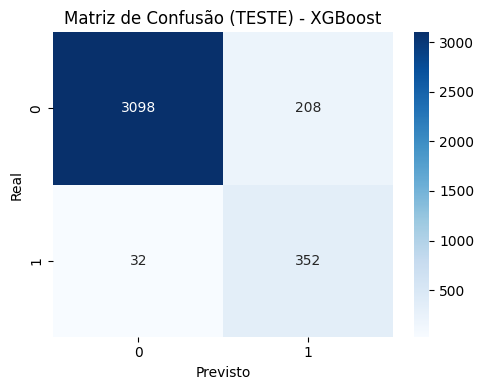

In [8]:
test_comparison = pd.DataFrame([
    metrics_row("XGBoost", xgb, X_test_scaled, y_test),
    metrics_row("MLP", mlp, X_test_scaled, y_test),
])
print("=== Ambos no TESTE (referência; a seleção foi na validação) ===")
print(test_comparison.to_string(index=False))

print("\n=== Métricas FINAIS — modelo escolhido (" + best_name + ") no TESTE ===")
test_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, test_pred, digits=3, zero_division=0))

cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de Confusão (TESTE) - {best_name}")
plt.xlabel("Previsto"); plt.ylabel("Real"); plt.tight_layout(); plt.show()


## 6. Interpretabilidade com SHAP (sobre o XGBoost)

O SHAP ensinado (Aula 06) é para modelos de árvore; a interpretabilidade é feita sobre o XGBoost, no conjunto de teste.

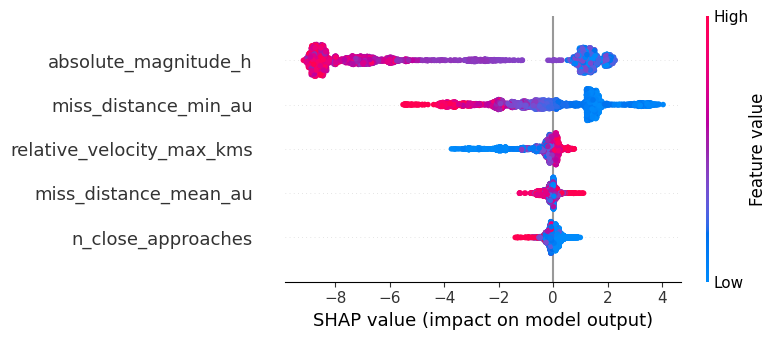

In [9]:
# SHAP sobre o XGBoost (modelo de árvore), no espaço escalado do teste.
explainer = shap.Explainer(xgb)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, show=True)


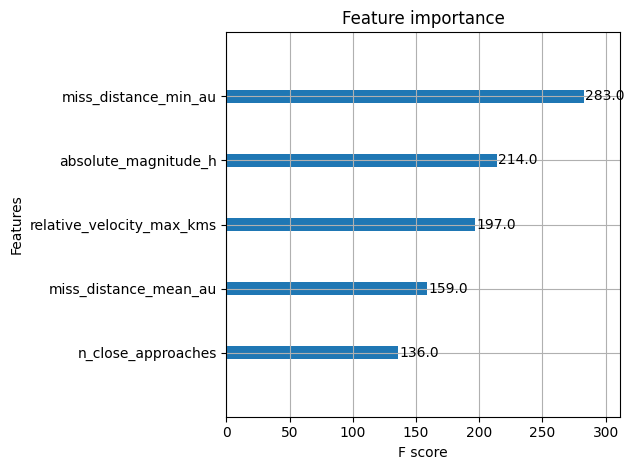

In [10]:
plot_importance(xgb)
plt.tight_layout(); plt.show()


**Interpretação:** espera-se que `absolute_magnitude_h` (tamanho) e as variáveis
de proximidade (`miss_distance_*`) dominem a decisão — coerente com a definição de
PHA (tamanho + proximidade), e consequência de manter a magnitude como feature.


## 7. Persistência do modelo final

Salvamos o modelo escolhido na validação + o scaler + a lista de features.

In [11]:
joblib.dump(
    {"model": best_model, "scaler": scaler, "features": FEATURE_COLUMNS, "best_name": best_name},
    "model.joblib",
)
print("modelo final salvo em model.joblib:", best_name)
print(test_comparison.to_string(index=False))


modelo final salvo em model.joblib: XGBoost
 modelo  accuracy  precision_PHA  recall_PHA   f1_PHA
XGBoost  0.934959       0.628571    0.916667 0.745763
    MLP  0.962331       0.876923    0.742188 0.803949
